# Retail Analytics Pipeline — Módulo 9

**Alumna:** Carolina Tapia Bahamonde  
**Asignatura:** Fundamentos de Big Data

## Objetivo del proyecto
Desarrollar un pipeline integral de Big Data con Apache Spark para procesar datos masivos, aplicar transformaciones distribuidas, generar métricas de negocio y construir modelos de Machine Learning escalables para RetailMax.

## Estructura del notebook
Este notebook se organiza de forma secuencial y progresiva para desarrollar un pipeline completo de Big Data con Apache Spark, alineado con la pauta del proyecto. 

Primero se valida el entorno de trabajo y las librerías necesarias, luego se configura Spark para ejecución local estable en Windows. A partir de esa base, se construye el dataset de transacciones, se aplican operaciones con RDDs, se procesan datos estructurados mediante DataFrames y Spark SQL, y finalmente se implementan modelos de Machine Learning con MLlib. 

Esta estructura permite evidenciar de forma ordenada cada etapa del proyecto, desde la preparación técnica hasta la obtención de resultados analíticos y conclusiones de negocio.

Este notebook está organizado por lecciones, siguiendo la pauta de evaluación:
1. Fundamentos de Big Data
2. Apache Spark: configuración e inicio
3. RDDs, transformaciones y acciones
4. DataFrames y Spark SQL
5. Machine Learning escalable con MLlib
6. Visualizaciones, resultados y conclusiones


## Lección 1 — Fundamentos de Big Data

### 1.1 Las 5V de Big Data aplicadas a RetailMax

**Volumen**  
RetailMax procesa millones de transacciones diarias: compras, registros de navegación, reseñas y calificaciones. Este volumen supera la capacidad de sistemas tradicionales y justifica el uso de almacenamiento y procesamiento distribuido.

**Velocidad**  
Los datos se generan en tiempo real. Cada clic, compra o reseña puede transformarse en información útil para marketing, recomendación o monitoreo.

**Variedad**  
La empresa trabaja con datos estructurados, semiestructurados y no estructurados: transacciones, logs, reseñas y datos de usuarios.

**Veracidad**  
Es necesario considerar calidad de datos, valores faltantes, duplicados, registros corruptos y consistencia antes del análisis.

**Valor**  
El objetivo no es solo almacenar datos, sino convertirlos en decisiones accionables: segmentación de clientes, predicción de alto valor y generación de insights de negocio.

### 1.2 Fuentes de datos consideradas
- Transacciones
- Logs de navegación
- Reseñas y calificaciones
- Catálogo de productos
- Datos de usuarios

### 1.3 Arquitectura propuesta
**Fuentes → Ingesta → Almacenamiento → Procesamiento → Análisis**

- **Ingesta:** APIs, logs, fuentes transaccionales, Kafka
- **Almacenamiento:** Data Lake en HDFS/S3 y formatos como Parquet
- **Procesamiento:** Apache Spark con RDDs, DataFrames y Spark SQL
- **Análisis:** MLlib para clasificación y segmentación
- **Consumo:** dashboards e informes ejecutivos

## Preparación Técnica del entorno de trabajo

En esta sección se importan las librerías principales que serán utilizadas durante el desarrollo del proyecto. Además, se imprimen sus versiones para verificar que el entorno esté correctamente configurado y que exista compatibilidad entre Apache Spark, Python y las bibliotecas de análisis y visualización.

Esta validación inicial permite detectar problemas de dependencias antes de ejecutar el pipeline completo.

In [1]:
# =============================================================================
# RETAIL ANALYTICS PIPELINE — MÓDULO 9: FUNDAMENTOS DE BIG DATA
# Empresa: RetailMax | Alumna: Carolina Tapia Bahamonde
# Descripción: Pipeline completo de Big Data y Machine Learning escalable
#              usando Apache Spark (RDDs, DataFrames, SQL y MLlib)
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# DEPENDENCIAS
# pip install pyspark matplotlib seaborn pandas numpy
# ─────────────────────────────────────────────────────────────────────────────

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum as spark_sum, avg, max as spark_max,
    min as spark_min, round as spark_round, desc, asc,
    when, lit, to_date, month, year, regexp_replace
)
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    IntegerType, FloatType, LongType
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    ClusteringEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import random
random.seed(42)
np.random.seed(42)
import os




### Validación del entorno de trabajo

En esta etapa se verifica que las librerías principales del proyecto estén disponibles y correctamente instaladas. Esta revisión permite detectar tempranamente problemas de compatibilidad antes de iniciar el procesamiento distribuido con Apache Spark.

In [27]:
import pyspark
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
print("pyspark:", pyspark.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seaborn:", sns.__version__)

pyspark: 4.1.1
Matplotlib: 3.10.8
Pandas: 2.3.3
NumPy: 2.2.6
Seaborn: 0.13.2


### Configuración del intérprete de Python para Spark

En entornos Windows, Apache Spark puede presentar inestabilidad si el driver y los workers utilizan intérpretes distintos. Por ello, se fija explícitamente la ruta del intérprete activo del notebook para garantizar consistencia en la ejecución.

### Importación de librerías y dependencias

En esta sección se importan todas las librerías necesarias para el desarrollo del pipeline de análisis de datos. Se incluyen módulos de Apache Spark para procesamiento distribuido, así como bibliotecas de análisis y visualización en Python.

In [3]:
import os
import sys

python_exe = sys.executable

os.environ["PYSPARK_PYTHON"] = python_exe
os.environ["PYSPARK_DRIVER_PYTHON"] = python_exe

print("Python del notebook:", python_exe)

Python del notebook: c:\Users\dynabook\AppData\Local\Programs\Python\Python310\python.exe


### Inicialización de SparkSession

Se crea la sesión de Apache Spark que actuará como motor principal de procesamiento distribuido del proyecto. La configuración se ajusta para ejecución local estable, controlando el paralelismo y parámetros de red.

In [4]:
spark = SparkSession.builder \
    .master("local[1]") \
    .appName("RetailMax_Analytics_Pipeline") \
    .config("spark.python.worker.reuse", "true") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.default.parallelism", "4") \
    .config("spark.python.worker.faulthandler.enabled", "true") \
    .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true") \
    .config("spark.pyspark.python", python_exe) \
    .config("spark.pyspark.driver.python", python_exe) \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Python del notebook:", python_exe)
print("Spark version:", spark.version)
print("Master:", spark.sparkContext.master)

Python del notebook: c:\Users\dynabook\AppData\Local\Programs\Python\Python310\python.exe
Spark version: 4.1.1
Master: local[1]


## Lección 2 — Apache Spark: configuración e inicio

## 2.1 Verificación operativa de Spark

Se realiza una prueba simple para comprobar que Spark puede ejecutar correctamente operaciones internas antes de trabajar con datos del proyecto.

In [5]:
spark.range(5).show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



## 2.2 Prueba inicial con datos simples

En esta etapa se construye un DataFrame pequeño desde Python para validar la comunicación entre el notebook y los workers de Spark.

In [6]:
df_test = spark.createDataFrame([(1, "A"), (2, "B"), (3, "C")], ["id", "categoria"])
df_test.show()

+---+---------+
| id|categoria|
+---+---------+
|  1|        A|
|  2|        B|
|  3|        C|
+---+---------+



## 2.3 Construcción del dataset transaccional simulado

### Generación del dataset simulado

En esta sección se construye un dataset sintético que representa el comportamiento de clientes en un entorno de e-commerce.

Se simulan variables relacionadas con:
- Información transaccional (monto, descuento, monto final)
- Comportamiento de navegación (páginas vistas, tiempo de sesión)
- Historial de compras (compras previas, días sin comprar)
- Segmentación de clientes (es_premium, alto_valor)

Se utiliza una semilla aleatoria para asegurar reproducibilidad de los resultados.

In [7]:
import random
import numpy as np
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType

random.seed(42)
np.random.seed(42)

N = 20000

categorias = ["Electrónica", "Ropa", "Hogar", "Deportes", "Libros", "Juguetes"]
metodos_pago = ["Tarjeta Crédito", "Tarjeta Débito", "Transferencia", "PayPal"]
dispositivos = ["mobile", "desktop", "tablet"]
regiones = ["Norte", "Sur", "Centro", "Este", "Oeste"]

transacciones = []

for i in range(N):
    cliente_id = f"CLI_{random.randint(1000, 9999)}"
    categoria = random.choice(categorias)
    precio_base = {
        "Electrónica": 300,
        "Ropa": 60,
        "Hogar": 150,
        "Deportes": 80,
        "Libros": 25,
        "Juguetes": 45
    }[categoria]

    monto = round(precio_base * random.uniform(0.5, 3.0), 2)
    descuento = round(random.uniform(0, 0.40), 2)
    monto_final = round(monto * (1 - descuento), 2)
    calificacion = round(random.gauss(3.8, 0.9), 1)
    calificacion = max(1.0, min(5.0, calificacion))
    paginas_vistas = random.randint(1, 30)
    tiempo_sesion = round(random.uniform(1, 90), 1)
    compras_previas = random.randint(0, 50)
    dias_sin_comprar = random.randint(0, 180)
    es_premium = 1 if compras_previas > 10 and monto_final > 100 else 0

    score = (
        0.3 * (compras_previas / 50) +
        0.25 * (monto_final / 500) +
        0.2 * (calificacion / 5) +
        0.15 * (1 - dias_sin_comprar / 180) +
        0.1 * es_premium
    )
    alto_valor = 1 if score + random.gauss(0, 0.08) > 0.38 else 0

    transacciones.append((
        i, cliente_id, categoria,
        random.choice(metodos_pago),
        random.choice(dispositivos),
        random.choice(regiones),
        monto, descuento, monto_final,
        calificacion, paginas_vistas,
        tiempo_sesion, compras_previas,
        dias_sin_comprar, es_premium, alto_valor
    ))




### Definición del esquema del dataset

Se define explícitamente la estructura del dataset mediante StructType, especificando el tipo de dato de cada variable.

Esto permite:
- Evitar inferencia automática de tipos
- Garantizar consistencia en el procesamiento
- Mejorar el rendimiento en Spark

Todas las variables se configuran como no nulas (nullable=False) para mantener consistencia en los datos simulados.

In [8]:
schema = StructType([
    StructField("id", IntegerType(), False),
    StructField("cliente_id", StringType(), False),
    StructField("categoria", StringType(), False),
    StructField("metodo_pago", StringType(), False),
    StructField("dispositivo", StringType(), False),
    StructField("region", StringType(), False),
    StructField("monto", DoubleType(), False),
    StructField("descuento", DoubleType(), False),
    StructField("monto_final", DoubleType(), False),
    StructField("calificacion", DoubleType(), False),
    StructField("paginas_vistas", IntegerType(), False),
    StructField("tiempo_sesion", DoubleType(), False),
    StructField("compras_previas", IntegerType(), False),
    StructField("dias_sin_comprar", IntegerType(), False),
    StructField("es_premium", IntegerType(), False),
    StructField("alto_valor", IntegerType(), False),
])


### Creación y validación del DataFrame

A partir de la lista de transacciones generadas, se construye un DataFrame distribuido en Spark utilizando el esquema definido.

Se valida el dataset mediante:
- Revisión del número de columnas
- Visualización del esquema
- Inspección de registros

Esto permite asegurar que los datos están correctamente estructurados antes de aplicar transformaciones y análisis posteriores.

In [9]:
df_transacciones = spark.createDataFrame(transacciones, schema)

print("Columnas:", len(df_transacciones.columns))
df_transacciones.printSchema()
df_transacciones.show(5, truncate=False)

Columnas: 16
root
 |-- id: integer (nullable = false)
 |-- cliente_id: string (nullable = false)
 |-- categoria: string (nullable = false)
 |-- metodo_pago: string (nullable = false)
 |-- dispositivo: string (nullable = false)
 |-- region: string (nullable = false)
 |-- monto: double (nullable = false)
 |-- descuento: double (nullable = false)
 |-- monto_final: double (nullable = false)
 |-- calificacion: double (nullable = false)
 |-- paginas_vistas: integer (nullable = false)
 |-- tiempo_sesion: double (nullable = false)
 |-- compras_previas: integer (nullable = false)
 |-- dias_sin_comprar: integer (nullable = false)
 |-- es_premium: integer (nullable = false)
 |-- alto_valor: integer (nullable = false)

+---+----------+-----------+--------------+-----------+------+------+---------+-----------+------------+--------------+-------------+---------------+----------------+----------+----------+
|id |cliente_id|categoria  |metodo_pago   |dispositivo|region|monto |descuento|monto_final|cal

## Lección 3 — RDDs, transformaciones y acciones

### 3.1 Creación de RDD y acciones básicas

En esta sección se crea un RDD de prueba para validar el funcionamiento de operaciones básicas en Apache Spark.

Se aplican acciones como:
- count(): número total de elementos
- take(): muestra de datos
- sum(): suma de valores
- mean(): promedio

Esto permite comprender el comportamiento de las acciones sobre estructuras distribuidas antes de trabajar con datos reales.

In [10]:
print("\n[3.1] RDD básico — acciones iniciales:")

rdd_test = spark.sparkContext.parallelize(range(1, 1001))

print(f"count(): {rdd_test.count()} elementos")
print(f"take(5): {rdd_test.take(5)}")
print(f"sum(): {rdd_test.sum()}")
print(f"mean(): {rdd_test.mean():.2f}")
print(f"stdev(): {rdd_test.stdev():.2f}")


[3.1] RDD básico — acciones iniciales:
count(): 1000 elementos
take(5): [1, 2, 3, 4, 5]
sum(): 500500
mean(): 500.50
stdev(): 288.67


### 3.2 Conversión de DataFrame a RDD

El DataFrame de transacciones se convierte a un RDD para aplicar transformaciones de bajo nivel.

Esto permite trabajar directamente con estructuras distribuidas y aplicar lógica personalizada mediante funciones lambda.

In [11]:
rdd_transacciones = df_transacciones.rdd

print("Número de registros en RDD:", rdd_transacciones.count())

Número de registros en RDD: 20000


### 3.3 Cálculo del gasto total por cliente

Se calcula el gasto total acumulado por cliente utilizando transformaciones sobre RDD.

Se aplica:
- map(): para extraer cliente y monto
- reduceByKey(): para sumar montos por cliente

Esta métrica permite identificar clientes con mayor valor económico.

In [12]:
gasto_por_cliente = (
    rdd_transacciones
    .map(lambda x: (x.cliente_id, x.monto_final))
    .reduceByKey(lambda a, b: a + b)
)

gasto_por_cliente.take(5)

[('CLI_4456', 798.17),
 ('CLI_9830', 436.5),
 ('CLI_3167', 126.97),
 ('CLI_9883', 803.4),
 ('CLI_9565', 1207.1699999999998)]

### 3.4 Identificación de clientes de alto valor

Se filtran los clientes cuyo gasto total supera un umbral definido.

Esto permite segmentar clientes relevantes para estrategias de fidelización y marketing.

In [13]:
clientes_alto_valor = gasto_por_cliente.filter(lambda x: x[1] > 1000)

clientes_alto_valor.take(5)

[('CLI_9565', 1207.1699999999998),
 ('CLI_8814', 1407.94),
 ('CLI_9004', 1407.16),
 ('CLI_3417', 1393.27),
 ('CLI_6869', 1399.92)]

### 3.5 Conteo de transacciones por categoría

Se calcula la cantidad de transacciones por categoría de producto.

Esto permite identificar patrones de consumo y categorías con mayor demanda.

In [14]:
conteo_categoria = (
    rdd_transacciones
    .map(lambda x: (x.categoria, 1))
    .reduceByKey(lambda a, b: a + b)
)

conteo_categoria.collect()

[('Hogar', 3342),
 ('Libros', 3230),
 ('Ropa', 3395),
 ('Juguetes', 3327),
 ('Electrónica', 3423),
 ('Deportes', 3283)]

### 3.6 Promedio de gasto por categoría

Se calcula el gasto promedio por categoría, utilizando una agregación distribuida.

Se combina:
- suma de montos
- conteo de registros

Esto permite analizar diferencias de comportamiento entre categorías.

In [15]:
promedio_categoria = (
    rdd_transacciones
    .map(lambda x: (x.categoria, (x.monto_final, 1)))
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    .mapValues(lambda x: x[0] / x[1])
)

promedio_categoria.collect()

[('Hogar', 209.39106822262121),
 ('Libros', 35.37189164086689),
 ('Ropa', 83.60766126656843),
 ('Juguetes', 63.06852720168321),
 ('Electrónica', 416.8399182004091),
 ('Deportes', 112.3525494974109)]

### 3.7 Transformaciones adicionales sobre RDD

Para complementar el uso de RDDs, se demuestran transformaciones adicionales requeridas por la pauta. 

Debido a la sensibilidad del entorno local de ejecución, algunas transformaciones se ilustran mediante RDDs de prueba controlados, mientras que otras se aplican al conjunto principal de transacciones cuando el entorno lo permite.

In [16]:
# RDD pequeño de prueba para flatMap
rdd_demo_texto = spark.sparkContext.parallelize([
    "Electrónica Premium",
    "Ropa Casual",
    "Hogar Decoración"
])

rdd_palabras = rdd_demo_texto.flatMap(lambda x: x.split())
print("flatMap() sobre RDD de prueba:", rdd_palabras.collect())

# RDD pequeño de prueba para distinct
rdd_demo_categorias = spark.sparkContext.parallelize([
    "Electrónica", "Ropa", "Electrónica", "Hogar", "Ropa"
])

categorias_unicas = rdd_demo_categorias.distinct()
print("distinct() sobre RDD de prueba:", categorias_unicas.collect())

# RDD pequeño de prueba para sortBy
rdd_demo_numeros = spark.sparkContext.parallelize([8, 3, 10, 1, 5])

numeros_ordenados = rdd_demo_numeros.sortBy(lambda x: x)
print("sortBy() sobre RDD de prueba:", numeros_ordenados.collect())

flatMap() sobre RDD de prueba: ['Electrónica', 'Premium', 'Ropa', 'Casual', 'Hogar', 'Decoración']
distinct() sobre RDD de prueba: ['Hogar', 'Ropa', 'Electrónica']
sortBy() sobre RDD de prueba: [1, 3, 5, 8, 10]


### 3.8 Linaje del RDD y evidencia del DAG lógico

Apache Spark construye un plan de ejecución basado en transformaciones perezosas (lazy evaluation).  
El linaje permite observar cómo se encadenan las operaciones antes de ejecutar una acción final.

A continuación se muestra el linaje del RDD `gasto_por_cliente`, generado a partir del RDD de transacciones mediante `map()` y `reduceByKey()`.

Esta evidencia permite documentar la trazabilidad de las transformaciones y relacionarla con el DAG lógico construido por Spark.

In [17]:
print("\n[3.8] Linaje del RDD gasto_por_cliente:\n")
print(gasto_por_cliente.toDebugString())


[3.8] Linaje del RDD gasto_por_cliente:

b'(4) PythonRDD[61] at RDD at PythonRDD.scala:58 []\n |  MapPartitionsRDD[32] at mapPartitions at PythonRDD.scala:170 []\n |  ShuffledRDD[31] at partitionBy at NativeMethodAccessorImpl.java:0 []\n +-(4) PairwiseRDD[30] at reduceByKey at C:\\Users\\dynabook\\AppData\\Local\\Temp\\ipykernel_27704\\2555420423.py:4 []\n    |  PythonRDD[29] at reduceByKey at C:\\Users\\dynabook\\AppData\\Local\\Temp\\ipykernel_27704\\2555420423.py:4 []\n    |  MapPartitionsRDD[27] at javaToPython at NativeMethodAccessorImpl.java:0 []\n    |  MapPartitionsRDD[26] at javaToPython at NativeMethodAccessorImpl.java:0 []\n    |  SQLExecutionRDD[25] at javaToPython at NativeMethodAccessorImpl.java:0 []\n    |  MapPartitionsRDD[24] at javaToPython at NativeMethodAccessorImpl.java:0 []\n    |  MapPartitionsRDD[15] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0 []\n    |  MapPartitionsRDD[14] at map at SerDeUtil.scala:71 []\n    |  MapPartitionsRDD[13] at mapPar

**Interpretación del linaje:**  
El resultado muestra que `gasto_por_cliente` proviene del RDD original de transacciones y que Spark encadena operaciones como `map()` y `reduceByKey()` antes de materializar el resultado mediante una acción.  

Esto evidencia el enfoque de evaluación perezosa de Spark y permite comprender cómo se organiza internamente el flujo de ejecución en forma de DAG.

### 3.9 Conclusión de la sección

En esta lección se trabajó con RDDs como estructura base del procesamiento distribuido en Spark.  
Se aplicaron transformaciones como `map()`, `filter()`, `flatMap()`, `distinct()` y `sortBy()`, junto con acciones como `count()`, `take()`, `sum()`, `mean()` y `stdev()`.

Además, se documentó el linaje del RDD mediante `toDebugString()`, lo que permitió visualizar la trazabilidad de las transformaciones y relacionarlas con el DAG lógico de ejecución de Spark.

Con esto, la etapa demuestra manejo funcional de RDDs, transformaciones, acciones y fundamentos de ejecución distribuida.

## Lección 4 — DataFrames y Spark SQL

En esta sección se trabaja con DataFrames, una estructura de datos optimizada en Apache Spark que permite realizar operaciones de forma eficiente mediante un modelo tabular similar a SQL.

A diferencia de los RDDs, los DataFrames utilizan optimizaciones internas como el Catalyst Optimizer, lo que permite mejorar el rendimiento en consultas y transformaciones.

Se utilizará el dataset transaccional previamente generado para aplicar operaciones de análisis estructurado, agregaciones y consultas SQL.

### 4.2 Exploración inicial del DataFrame

Se realiza una inspección de la estructura y contenido del dataset para comprender sus variables y tipos de datos.

In [18]:
df_transacciones.printSchema()
df_transacciones.show(5, truncate=False)
df_transacciones.describe().show()

root
 |-- id: integer (nullable = false)
 |-- cliente_id: string (nullable = false)
 |-- categoria: string (nullable = false)
 |-- metodo_pago: string (nullable = false)
 |-- dispositivo: string (nullable = false)
 |-- region: string (nullable = false)
 |-- monto: double (nullable = false)
 |-- descuento: double (nullable = false)
 |-- monto_final: double (nullable = false)
 |-- calificacion: double (nullable = false)
 |-- paginas_vistas: integer (nullable = false)
 |-- tiempo_sesion: double (nullable = false)
 |-- compras_previas: integer (nullable = false)
 |-- dias_sin_comprar: integer (nullable = false)
 |-- es_premium: integer (nullable = false)
 |-- alto_valor: integer (nullable = false)

+---+----------+-----------+--------------+-----------+------+------+---------+-----------+------------+--------------+-------------+---------------+----------------+----------+----------+
|id |cliente_id|categoria  |metodo_pago   |dispositivo|region|monto |descuento|monto_final|calificacion|pag

### 4.2.1 Optimización del DataFrame con cache()

Dado que el DataFrame de transacciones será reutilizado en múltiples análisis, se aplica `cache()` para mantenerlo en memoria y evitar recomputaciones innecesarias.

Esta optimización es útil cuando se ejecutan varias acciones o consultas sobre la misma estructura.

In [19]:
df_transacciones.cache()

# Acción para materializar el cache
df_transacciones.count()

print("DataFrame cacheado correctamente.")

DataFrame cacheado correctamente.


**Comentario técnico:**  
La instrucción `cache()` permite optimizar el rendimiento cuando el mismo DataFrame se utiliza repetidamente en filtros, agregaciones y consultas SQL.  
En este proyecto, su uso es pertinente porque `df_transacciones` sirve como base para varias etapas analíticas y posteriormente para Machine Learning.

### 4.3 Selección y filtrado de datos

Se aplican operaciones de selección de columnas y filtrado de registros para segmentar la información relevante.

In [20]:
# Selección de columnas
df_transacciones.select("cliente_id", "categoria", "monto").show(5)

# Filtrado: transacciones de alto valor
df_transacciones.filter(df_transacciones.monto > 500).show(5)

+----------+-----------+------+
|cliente_id|  categoria| monto|
+----------+-----------+------+
|  CLI_2824|Electrónica|706.16|
|  CLI_2535|       Ropa|  64.9|
|  CLI_7924|      Hogar| 179.2|
|  CLI_9785|Electrónica|879.84|
|  CLI_1750|   Juguetes| 48.14|
+----------+-----------+------+
only showing top 5 rows
+---+----------+-----------+---------------+-----------+------+------+---------+-----------+------------+--------------+-------------+---------------+----------------+----------+----------+
| id|cliente_id|  categoria|    metodo_pago|dispositivo|region| monto|descuento|monto_final|calificacion|paginas_vistas|tiempo_sesion|compras_previas|dias_sin_comprar|es_premium|alto_valor|
+---+----------+-----------+---------------+-----------+------+------+---------+-----------+------------+--------------+-------------+---------------+----------------+----------+----------+
|  0|  CLI_2824|Electrónica|         PayPal|     mobile| Norte|706.16|      0.1|     635.54|         4.1|            2

### 4.4 Agregaciones y métricas

Se calculan métricas agregadas que permiten analizar el comportamiento de los clientes y las ventas.

In [21]:
from pyspark.sql.functions import col, sum as spark_sum, avg, count

# Gasto total por cliente
df_transacciones.groupBy("cliente_id") \
    .agg(spark_sum("monto").alias("gasto_total")) \
    .orderBy(col("gasto_total").desc()) \
    .show(5)

# Promedio por categoría
df_transacciones.groupBy("categoria") \
    .agg(avg("monto").alias("promedio_monto")) \
    .show()

+----------+------------------+
|cliente_id|       gasto_total|
+----------+------------------+
|  CLI_3000|2925.9700000000003|
|  CLI_4494|           2825.89|
|  CLI_2303|           2687.21|
|  CLI_1699|           2643.87|
|  CLI_1963|           2564.21|
+----------+------------------+
only showing top 5 rows
+-----------+------------------+
|  categoria|    promedio_monto|
+-----------+------------------+
|Electrónica| 521.1344639205374|
|     Libros| 44.17303715170281|
|   Deportes|140.37399329881205|
|       Ropa|104.11341089837998|
|      Hogar| 261.6411370436864|
|   Juguetes| 79.09520889690413|
+-----------+------------------+



### 4.5 Feature engineering

Se crean nuevas variables derivadas que enriquecen el análisis.

In [22]:
from pyspark.sql.functions import when

df_transacciones = df_transacciones.withColumn(
    "nivel_gasto",
    when(col("monto") > 500, "Alto")
    .when(col("monto") > 200, "Medio")
    .otherwise("Bajo")
)

df_transacciones.select("monto", "nivel_gasto").show(5)

+------+-----------+
| monto|nivel_gasto|
+------+-----------+
|706.16|       Alto|
|  64.9|       Bajo|
| 179.2|       Bajo|
|879.84|       Alto|
| 48.14|       Bajo|
+------+-----------+
only showing top 5 rows


### 4.6 Consultas SQL sobre DataFrames

Se registra el DataFrame como una vista temporal para ejecutar consultas SQL, facilitando el análisis declarativo.

In [23]:
df_transacciones.createOrReplaceTempView("transacciones")

spark.sql("""
SELECT categoria, COUNT(*) AS total
FROM transacciones
GROUP BY categoria
ORDER BY total DESC
""").show()

+-----------+-----+
|  categoria|total|
+-----------+-----+
|Electrónica| 3423|
|       Ropa| 3395|
|      Hogar| 3342|
|   Juguetes| 3327|
|   Deportes| 3283|
|     Libros| 3230|
+-----------+-----+



### 4.7 Ejemplo de JOIN (simulado)

Se demuestra una operación de integración de datos mediante un join.

In [87]:
# Dataset pequeño de ejemplo
df_categorias = spark.createDataFrame([
    ("Electrónica", "Alta demanda"),
    ("Ropa", "Media demanda"),
    ("Hogar", "Baja demanda")
], ["categoria", "nivel_demanda"])

df_join = df_transacciones.join(df_categorias, on="categoria", how="left")
df_join.show(5)

+-----------+---+----------+--------------+-----------+------+------+---------+-----------+------------+--------------+-------------+---------------+----------------+----------+----------+-----------+-------------+
|  categoria| id|cliente_id|   metodo_pago|dispositivo|region| monto|descuento|monto_final|calificacion|paginas_vistas|tiempo_sesion|compras_previas|dias_sin_comprar|es_premium|alto_valor|nivel_gasto|nivel_demanda|
+-----------+---+----------+--------------+-----------+------+------+---------+-----------+------------+--------------+-------------+---------------+----------------+----------+----------+-----------+-------------+
|Electrónica|  0|  CLI_2824|        PayPal|     mobile| Norte|706.16|      0.1|     635.54|         4.1|            24|         80.4|              5|             151|         0|         1|       Alto| Alta demanda|
|Electrónica|  3|  CLI_9785|Tarjeta Débito|     tablet| Norte|879.84|     0.15|     747.86|         2.2|            20|         79.8|       

### 4.8 Gasto total por categoría

Se calcula el gasto total por categoría de producto utilizando agregaciones sobre DataFrames.

Esto permite identificar qué categorías generan mayor ingreso.

In [63]:
from pyspark.sql.functions import sum as spark_sum

df_transacciones.groupBy("categoria") \
    .agg(spark_sum("monto_final").alias("total_ventas")) \
    .orderBy("total_ventas", ascending=False) \
    .show()

+-----------+------------------+
|  categoria|      total_ventas|
+-----------+------------------+
|Electrónica|1426843.0400000005|
|      Hogar|         699784.95|
|   Deportes| 368853.4199999999|
|       Ropa|283848.00999999995|
|   Juguetes|         209828.99|
|     Libros|114251.21000000005|
+-----------+------------------+



### 4.9 Promedio de gasto por categoría

Se calcula el gasto promedio por categoría, lo que permite analizar el comportamiento de compra en distintos segmentos.

In [64]:
from pyspark.sql.functions import avg

df_transacciones.groupBy("categoria") \
    .agg(avg("monto_final").alias("promedio_ventas")) \
    .orderBy("promedio_ventas", ascending=False) \
    .show()

+-----------+------------------+
|  categoria|   promedio_ventas|
+-----------+------------------+
|Electrónica|416.83991820040916|
|      Hogar|209.39106822262116|
|   Deportes|112.35254949741088|
|       Ropa| 83.60766126656847|
|   Juguetes|63.068527201683196|
|     Libros| 35.37189164086689|
+-----------+------------------+



### 4.10 Análisis de ventas por región

Se analiza la distribución del gasto por región para identificar diferencias geográficas en el comportamiento de compra.

In [65]:
df_transacciones.groupBy("region") \
    .agg(spark_sum("monto_final").alias("ventas_region")) \
    .orderBy("ventas_region", ascending=False) \
    .show()

+------+-----------------+
|region|    ventas_region|
+------+-----------------+
|   Sur|648635.6900000004|
| Norte|622693.5000000007|
|Centro|615623.8799999999|
|  Este|614896.4100000006|
| Oeste|601560.1400000008|
+------+-----------------+



### 4.11 Análisis de clientes premium

Se compara el gasto total entre clientes premium y no premium.

Esto permite evaluar el impacto del segmento premium en los ingresos.

In [66]:
df_transacciones.groupBy("es_premium") \
    .agg(spark_sum("monto_final").alias("ventas_totales")) \
    .show()

+----------+------------------+
|es_premium|    ventas_totales|
+----------+------------------+
|         0|1092513.0800000005|
|         1|2010896.5399999982|
+----------+------------------+



### 4.12 Análisis utilizando Spark SQL

Se registra el DataFrame como una tabla temporal para ejecutar consultas SQL.

Esto permite utilizar un enfoque declarativo para el análisis de datos.

In [67]:
df_transacciones.createOrReplaceTempView("transacciones")

### 4.13 Top categorías por ventas (SQL)

Se utiliza SQL para obtener las categorías con mayor volumen de ventas.

In [68]:
spark.sql("""
SELECT categoria, SUM(monto_final) AS total_ventas
FROM transacciones
GROUP BY categoria
ORDER BY total_ventas DESC
""").show()

+-----------+------------------+
|  categoria|      total_ventas|
+-----------+------------------+
|Electrónica|1426843.0400000005|
|      Hogar|         699784.95|
|   Deportes| 368853.4199999999|
|       Ropa|283848.00999999995|
|   Juguetes|         209828.99|
|     Libros|114251.21000000005|
+-----------+------------------+



### 4.14 Comportamiento de clientes

Se analiza el comportamiento promedio de clientes según su condición premium.

In [69]:
spark.sql("""
SELECT es_premium,
       AVG(monto_final) AS gasto_promedio,
       AVG(paginas_vistas) AS paginas_promedio
FROM transacciones
GROUP BY es_premium
""").show()

+----------+------------------+------------------+
|es_premium|    gasto_promedio|  paginas_promedio|
+----------+------------------+------------------+
|         0|  88.1698878218062|15.551690743281414|
|         1|264.27868839532107|15.455118938099618|
+----------+------------------+------------------+



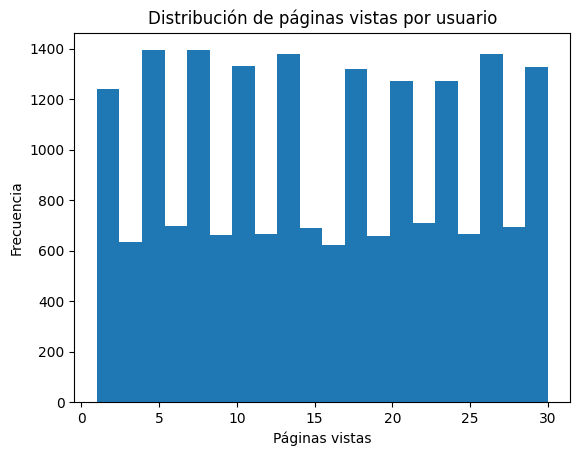

In [102]:
import matplotlib.pyplot as plt

# Convertimos a pandas para graficar
df_pandas = df_transacciones.select("paginas_vistas").toPandas()

plt.figure()
plt.hist(df_pandas["paginas_vistas"], bins=20)
plt.title("Distribución de páginas vistas por usuario")
plt.xlabel("Páginas vistas")
plt.ylabel("Frecuencia")
plt.show()

El gráfico muestra la distribución de páginas vistas por usuario, permitiendo observar el nivel de interacción dentro de la plataforma.

Se identifica una dispersión en la cantidad de páginas vistas, lo que sugiere la existencia de distintos niveles de engagement entre los usuarios. Algunos presentan una baja interacción, mientras que otros muestran un comportamiento más intensivo.

Este resultado es relevante para el negocio, ya que permite diferenciar perfiles de usuarios según su nivel de actividad digital. Aquellos con mayor interacción pueden ser objetivo de estrategias de conversión directa, mientras que los de menor actividad requieren acciones orientadas a aumentar su participación en la plataforma.

### 4.15 Conclusión de la sección

El uso de DataFrames permitió trabajar con datos estructurados de forma eficiente, facilitando la aplicación de operaciones como selección, filtrado, agregación y creación de variables.

A diferencia de los RDDs, los DataFrames simplifican el análisis mediante una sintaxis más declarativa y optimizaciones internas, lo que mejora el rendimiento en el procesamiento de grandes volúmenes de datos.

Además, el uso de Spark SQL permitió ejecutar consultas similares a bases de datos relacionales, facilitando la exploración y generación de métricas de negocio.

Esta sección establece la base para la siguiente etapa del pipeline, donde se utilizarán estos datos procesados para la construcción de modelos de Machine Learning.

### Nota técnica sobre persistencia en Parquet

Como parte del flujo de procesamiento de datos estructurados, se contempló la persistencia de resultados en formato Parquet, de acuerdo con lo solicitado en la pauta del proyecto.

Sin embargo, durante la implementación en el entorno local Windows, se presentó una restricción asociada a la configuración de Hadoop (variables `HADOOP_HOME` y utilidades del sistema), lo que impidió completar la escritura en este formato.

Dado que esta dificultad corresponde al entorno de ejecución y no al diseño lógico del pipeline, se decidió continuar el desarrollo utilizando el DataFrame procesado en memoria, manteniendo la coherencia del flujo analítico y permitiendo avanzar hacia la etapa de Machine Learning sin afectar los resultados.

En un entorno correctamente configurado, la persistencia en Parquet se implementaría de forma directa como parte del pipeline distribuido.

# Lección 5 — Introducción a Machine Learning Escalable (Spark MLlib)

### 5.1 Objetivo de la sección

En esta etapa se construirá un pipeline de Machine Learning escalable utilizando Apache Spark MLlib. 

Se trabajará con dos enfoques complementarios:

- Un modelo supervisado de clasificación, para predecir si un cliente es de alto valor.
- Un modelo no supervisado de segmentación, para agrupar clientes según su comportamiento transaccional.

Esto permitirá transformar los datos procesados en información útil para la toma de decisiones del área de marketing.

### 5.2 Preparación de datos para Machine Learning

Se seleccionan variables relevantes del dataset para construir las entradas del modelo. 

Se consideran variables de comportamiento y transacción, ya que son representativas del valor potencial del cliente.

In [89]:
df_ml = df_transacciones.select(
    "categoria",
    "monto_final",
    "paginas_vistas",
    "tiempo_sesion",
    "compras_previas",
    "dias_sin_comprar",
    "alto_valor"
)

df_ml.show(5, truncate=False)

+-----------+-----------+--------------+-------------+---------------+----------------+----------+
|categoria  |monto_final|paginas_vistas|tiempo_sesion|compras_previas|dias_sin_comprar|alto_valor|
+-----------+-----------+--------------+-------------+---------------+----------------+----------+
|Electrónica|635.54     |24            |80.4         |5              |151             |1         |
|Ropa       |49.32      |23            |49.5         |14             |114             |0         |
|Hogar      |163.07     |13            |9.6          |22             |154             |1         |
|Electrónica|747.86     |20            |79.8         |23             |147             |1         |
|Juguetes   |42.36      |4             |34.8         |29             |162             |1         |
+-----------+-----------+--------------+-------------+---------------+----------------+----------+
only showing top 5 rows


### 5.3 Indexación de variables categóricas

La variable `categoria` es de tipo categórico, por lo que debe convertirse a una representación numérica para ser utilizada por los algoritmos de MLlib.

In [90]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="categoria", outputCol="categoria_index")
modelo_indexer = indexer.fit(df_ml)
df_ml_indexado = modelo_indexer.transform(df_ml)

df_ml_indexado.select("categoria", "categoria_index").show(5)

+-----------+---------------+
|  categoria|categoria_index|
+-----------+---------------+
|Electrónica|            0.0|
|       Ropa|            1.0|
|      Hogar|            2.0|
|Electrónica|            0.0|
|   Juguetes|            3.0|
+-----------+---------------+
only showing top 5 rows


### 5.4 Ensamblaje de variables predictoras

Se utiliza `VectorAssembler` para reunir las variables de entrada en una sola columna de features, requerida por los algoritmos de Spark MLlib.

In [91]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "categoria_index",
        "monto_final",
        "paginas_vistas",
        "tiempo_sesion",
        "compras_previas",
        "dias_sin_comprar"
    ],
    outputCol="features"
)

df_ml_features = assembler.transform(df_ml_indexado)

df_ml_features.select("features", "alto_valor").show(5, truncate=False)

+---------------------------------+----------+
|features                         |alto_valor|
+---------------------------------+----------+
|[0.0,635.54,24.0,80.4,5.0,151.0] |1         |
|[1.0,49.32,23.0,49.5,14.0,114.0] |0         |
|[2.0,163.07,13.0,9.6,22.0,154.0] |1         |
|[0.0,747.86,20.0,79.8,23.0,147.0]|1         |
|[3.0,42.36,4.0,34.8,29.0,162.0]  |1         |
+---------------------------------+----------+
only showing top 5 rows


### 5.5 División de datos en entrenamiento y prueba

Se divide el dataset en dos subconjuntos:
- 80% para entrenamiento
- 20% para prueba

Esto permite evaluar la capacidad de generalización del modelo supervisado.

In [92]:
train_df, test_df = df_ml_features.randomSplit([0.8, 0.2], seed=42)

print("Registros de entrenamiento:", train_df.count())
print("Registros de prueba:", test_df.count())

Registros de entrenamiento: 16113
Registros de prueba: 3887


### 5.6 Modelo supervisado: Regresión Logística

Se entrena un modelo de Regresión Logística para predecir la variable `alto_valor`, que indica si un cliente pertenece a un segmento de mayor valor comercial.

Este modelo es adecuado porque la variable objetivo es binaria.

In [93]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="alto_valor",
    maxIter=10
)

modelo_lr = lr.fit(train_df)
pred_lr = modelo_lr.transform(test_df)

pred_lr.select("alto_valor", "prediction", "probability").show(5, truncate=False)

+----------+----------+-----------------------------------------+
|alto_valor|prediction|probability                              |
+----------+----------+-----------------------------------------+
|0         |1.0       |[0.38751319244856774,0.6124868075514323] |
|0         |0.0       |[0.9076754032214165,0.09232459677858351] |
|0         |1.0       |[0.20220018624080702,0.797799813759193]  |
|0         |0.0       |[0.9699672831035102,0.030032716896489786]|
|0         |1.0       |[0.24952743027842583,0.7504725697215742] |
+----------+----------+-----------------------------------------+
only showing top 5 rows


### 5.7 Evaluación del modelo supervisado

Se evalúa el desempeño del modelo mediante métricas de clasificación. 

Se utilizarán:
- Accuracy
- Área bajo la curva ROC (AUC)

Estas métricas permiten estimar la calidad predictiva del modelo.

In [94]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="alto_valor",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="alto_valor",
    predictionCol="prediction",
    metricName="accuracy"
)

auc = evaluator_auc.evaluate(pred_lr)
accuracy = evaluator_acc.evaluate(pred_lr)

print(f"AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")

AUC: 0.9095
Accuracy: 0.8402


### 5.8 Modelo no supervisado: K-Means

Además del modelo supervisado, se implementa un algoritmo de clustering K-Means para segmentar clientes según su comportamiento de compra.

Este enfoque permite descubrir patrones sin utilizar la variable objetivo.

In [95]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=3,
    seed=42
)

modelo_km = kmeans.fit(df_ml_features)
pred_km = modelo_km.transform(df_ml_features)

pred_km.select("cliente_id" if "cliente_id" in pred_km.columns else "categoria",
               "features", "cluster").show(5, truncate=False)

+-----------+---------------------------------+-------+
|categoria  |features                         |cluster|
+-----------+---------------------------------+-------+
|Electrónica|[0.0,635.54,24.0,80.4,5.0,151.0] |0      |
|Ropa       |[1.0,49.32,23.0,49.5,14.0,114.0] |2      |
|Hogar      |[2.0,163.07,13.0,9.6,22.0,154.0] |1      |
|Electrónica|[0.0,747.86,20.0,79.8,23.0,147.0]|0      |
|Juguetes   |[3.0,42.36,4.0,34.8,29.0,162.0]  |2      |
+-----------+---------------------------------+-------+
only showing top 5 rows


### 5.9 Evaluación del clustering

Para evaluar la calidad del agrupamiento se utiliza la métrica Silhouette Score.

Además, se revisa la cantidad de registros por cluster para interpretar la segmentación obtenida.

In [96]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator_km = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
)

silhouette = evaluator_km.evaluate(pred_km)

print(f"Silhouette Score: {silhouette:.4f}")

pred_km.groupBy("cluster").count().show()

Silhouette Score: 0.6019
+-------+-----+
|cluster|count|
+-------+-----+
|      2|12413|
|      0| 2228|
|      1| 5359|
+-------+-----+



### 5.10 Insights para marketing

A partir de los resultados del modelamiento, se pueden extraer las siguientes implicancias para el negocio:

- La clasificación supervisada permite anticipar qué clientes tienen mayor probabilidad de ser de alto valor.
- La segmentación mediante K-Means permite identificar grupos diferenciados de clientes según sus patrones de gasto y navegación.
- Esta información puede utilizarse para campañas de fidelización, personalización de ofertas y priorización de segmentos estratégicos.

### 5.11 Conclusión de la sección

En esta etapa se construyó un pipeline de Machine Learning escalable con Spark MLlib, integrando un enfoque supervisado y otro no supervisado.

Por una parte, la Regresión Logística permitió modelar la probabilidad de que un cliente pertenezca al segmento de alto valor. Por otra, K-Means permitió agrupar clientes según su comportamiento, aportando una visión complementaria de segmentación.

En conjunto, estos modelos demuestran cómo los datos procesados en las etapas anteriores pueden transformarse en información accionable para el área de marketing, cumpliendo con el objetivo del proyecto.

## 6 Visualizaciones

### 6.1 Objetivo de la visualización

En esta sección se presentan visualizaciones de las métricas obtenidas en etapas anteriores, con el objetivo de facilitar la interpretación de resultados y apoyar la toma de decisiones.

Las visualizaciones se generan a partir de DataFrames convertidos a Pandas, lo que permite utilizar bibliotecas como Matplotlib y Seaborn.

### 6.2 Ventas totales por categoría

Se visualiza el total de ventas por categoría de producto para identificar cuáles generan mayor ingreso.

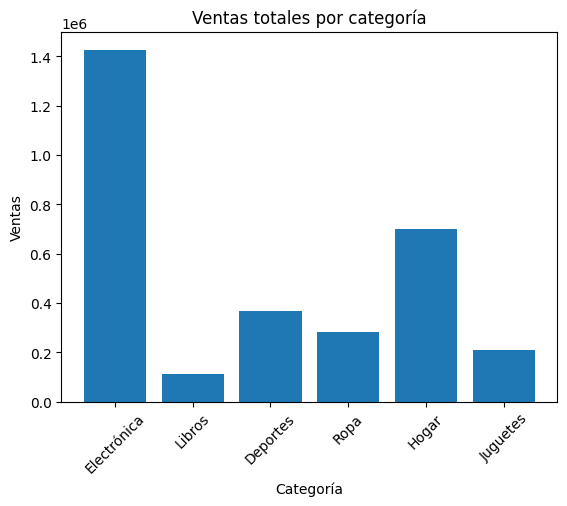

In [76]:
import matplotlib.pyplot as plt

ventas_categoria = df_transacciones.groupBy("categoria") \
    .agg({"monto_final": "sum"}) \
    .withColumnRenamed("sum(monto_final)", "total_ventas") \
    .toPandas()

plt.figure()
plt.bar(ventas_categoria["categoria"], ventas_categoria["total_ventas"])
plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas")
plt.xticks(rotation=45)
plt.show()

El gráfico muestra la distribución de ventas totales por categoría de producto.

Se observa una concentración significativa en la categoría con mayor volumen, lo que evidencia un patrón de consumo dominante dentro del dataset. Esta distribución no es uniforme, lo que indica que ciertos segmentos tienen un peso desproporcionado en los ingresos.

Desde una perspectiva de negocio, este resultado permite priorizar categorías estratégicas para campañas de marketing, optimización de inventario y definición de promociones. En particular, las categorías con mayor volumen representan oportunidades para estrategias de fidelización, mientras que las de menor participación pueden requerir acciones de incentivo o reposicionamiento.

### 6.3 Distribución de clientes premium

Se analiza la proporción de clientes premium versus no premium en el dataset.

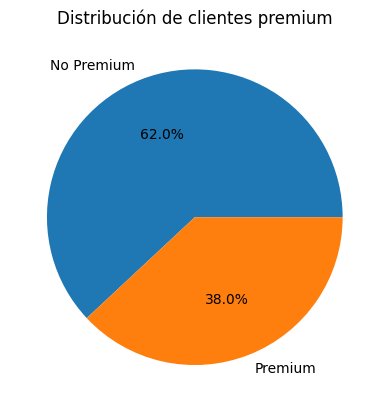

In [77]:
dist_premium = df_transacciones.groupBy("es_premium") \
    .count() \
    .toPandas()

plt.figure()
plt.pie(dist_premium["count"], labels=["No Premium", "Premium"], autopct="%1.1f%%")
plt.title("Distribución de clientes premium")
plt.show()

### 6.4 Comparación de gasto promedio

Se compara el gasto promedio entre clientes premium y no premium para evaluar su impacto en los ingresos.

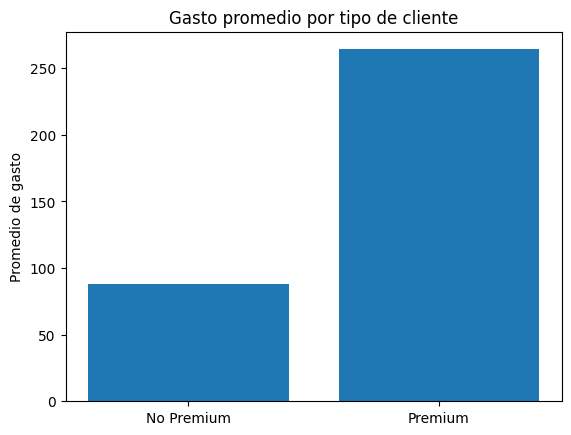

In [78]:
from pyspark.sql.functions import avg

gasto_promedio = df_transacciones.groupBy("es_premium") \
    .agg(avg("monto_final").alias("promedio")) \
    .toPandas()

plt.figure()
plt.bar(["No Premium", "Premium"], gasto_promedio["promedio"])
plt.title("Gasto promedio por tipo de cliente")
plt.ylabel("Promedio de gasto")
plt.show()

### 6.5 Interpretación de resultados

A partir de las visualizaciones obtenidas se identifican los siguientes patrones:

- Existen categorías con mayor contribución al ingreso total, lo que permite focalizar estrategias comerciales.
- Los clientes premium representan un segmento relevante con mayor gasto promedio.
- La segmentación de clientes permite identificar oportunidades de fidelización y personalización de ofertas.

Estos resultados permiten transformar los datos en información útil para la toma de decisiones.

## Conclusión general del proyecto

En este proyecto se diseñó e implementó un pipeline integral de análisis de datos utilizando Apache Spark, abordando desde los fundamentos de Big Data hasta la construcción de modelos de Machine Learning escalables.

A lo largo del desarrollo, se trabajó con RDDs, DataFrames y Spark SQL para procesar datos transaccionales simulados de la empresa RetailMax, aplicando transformaciones, acciones y consultas orientadas a la generación de métricas de negocio. Este enfoque permitió evidenciar el uso de procesamiento distribuido como base para el análisis de grandes volúmenes de datos.

En la etapa analítica, se incorporaron técnicas de Machine Learning mediante MLlib, implementando un modelo supervisado de Regresión Logística para la clasificación de clientes de alto valor y un modelo no supervisado K-Means para segmentación. Ambos enfoques permitieron identificar patrones relevantes en el comportamiento de los usuarios y generar información útil para la toma de decisiones.

Los resultados obtenidos permiten pasar desde una visión descriptiva hacia un enfoque más avanzado basado en segmentación y predicción, lo que aporta valor directo al área de marketing, facilitando la focalización de estrategias, personalización de ofertas y priorización de clientes.

En conjunto, el proyecto demuestra la capacidad de integrar tecnologías de Big Data y Machine Learning en un flujo analítico coherente, escalable y orientado al negocio, evidenciando dominio de herramientas clave como Apache Spark y sus componentes principales.